# Actividad 3 — Analisis Exploratorio de Datos (EDA)

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Explorar visualmente y estadisticamente las 4 fuentes de datos para entender distribuciones, tendencias, estacionalidad, correlaciones y relaciones entre variables. **No se modifica ni limpia ningun dato en esta actividad.**

## Graficos incluidos
| # | Fuente | Grafico |
|---|--------|---------|
| G1 | MIDAGRI | Produccion de limon por departamento (Pareto) |
| G2 | MIDAGRI | Serie temporal de produccion mensual |
| G3 | MIDAGRI | Distribucion de precios en chacra |
| G4 | MIDAGRI | Correlacion produccion vs precio |
| G5 | MIDAGRI | Estacionalidad mensual de la produccion |
| G6 | INDECI | Fenomenos hidrometeorologicos por frecuencia |
| G7 | INDECI | Emergencias por departamento productor de limon |
| G8 | INDECI | Serie temporal de emergencias mensuales |
| G9 | INDECI | Emergencias vs produccion de limon |
| G10 | NASA | Distribuciones de las 8 variables climaticas |
| G11 | NASA | Series temporales climaticas para provincias clave |
| G12 | NASA | Correlacion entre variables climaticas |
| G13 | NASA | Correlacion clima vs produccion de limon |
| G14 | NASA | Estacionalidad climatica mensual |
| G15 | Agraria.pe | Noticias por categoria y serie temporal |
| G16 | Todas | Correlacion cruzada entre todas las fuentes |


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de todas las fuentes


In [2]:
# ── MIDAGRI ──────────────────────────────────────────────────────────────
xl = pd.ExcelFile(SOURCES['midagri'])
dfs_m = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs_m, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
df_limon['fecha_mes'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
prod_mensual = df_limon.groupby('fecha_mes').agg(
    produccion_t=('PRODUCCION(t)','sum'),
    precio_kg=('MTO_PRECCHAC (S/ x kg)','mean')
).reset_index()

# ── NASA ──────────────────────────────────────────────────────────────────
df_nasa = pd.read_csv(OUTPUT['lectura'] + 'nasa_long_raw.csv', low_memory=False)
VARS_CLIMA = [c for c in df_nasa.columns if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
df_nasa['fecha_mes'] = pd.to_datetime(
    df_nasa['YEAR'].astype(str) + '-' + df_nasa['MES'].astype(str).str.zfill(2) + '-01'
)
clima_nacional = df_nasa.groupby('fecha_mes')[VARS_CLIMA].mean().reset_index()

# ── INDECI ────────────────────────────────────────────────────────────────
dfs_shp = []
for d in sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/')):
    shp = glob.glob(d + '*.shp')
    if shp:
        gdf = gpd.read_file(shp[0])
        df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
        df_tmp.columns = [str(c).lower() for c in df_tmp.columns]
        dfs_shp.append(df_tmp)
df_indeci = pd.concat(dfs_shp, ignore_index=True)
FENOMENOS_AGRO = CONFIG['fenomenos_indeci']
df_agro = df_indeci[df_indeci['fenomeno'].str.upper().isin(
    [normalizar(f) for f in FENOMENOS_AGRO])].copy()

# La columna 'mes' puede ser texto en español (ENERO, FEBRERO...) o numero
# Mapear a numero para construir fecha_mes correctamente
MESES_ES = {
    'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
    'JULIO':7,'AGOSTO':8,'SETIEMBRE':9,'SEPTIEMBRE':9,'OCTUBRE':10,
    'NOVIEMBRE':11,'DICIEMBRE':12
}

def mes_a_num(v):
    try:
        n = int(v)
        return n if 1 <= n <= 12 else None
    except (ValueError, TypeError):
        return MESES_ES.get(str(v).upper().strip(), None)

df_agro['mes_num'] = df_agro['mes'].apply(mes_a_num)
df_agro['fecha_mes'] = pd.to_datetime(
    df_agro['anho'].astype(str) + '-' +
    df_agro['mes_num'].fillna(1).astype(int).astype(str).str.zfill(2) + '-01',
    errors='coerce'
)
# Marcar como NaT las filas donde mes_num era None
df_agro.loc[df_agro['mes_num'].isna(), 'fecha_mes'] = pd.NaT

emer_mensual = df_agro.groupby('fecha_mes').size().reset_index(name='n_emergencias')
emer_mensual = emer_mensual.dropna(subset=['fecha_mes'])

print(f'INDECI agro: {len(df_agro):,} eventos | {len(emer_mensual)} meses')
print(f'Meses disponibles: {sorted(emer_mensual["fecha_mes"].dt.strftime("%Y-%m").tolist())}')

# ── AGRARIA ───────────────────────────────────────────────────────────────
df_agr = pd.read_csv(OUTPUT['lectura'] + 'agraria_raw.csv', on_bad_lines='skip', low_memory=False)
df_agr['fecha_mes'] = pd.to_datetime(df_agr['fecha'], errors='coerce').dt.to_period('M').dt.to_timestamp()
noticias_mensual = df_agr.groupby('fecha_mes').size().reset_index(name='n_noticias')

print('Fuentes cargadas:')
print(f'  MIDAGRI limon: {len(df_limon):,} registros | {len(prod_mensual)} meses')
print(f'  NASA clima: {len(df_nasa):,} registros | {len(clima_nacional)} meses')
print(f'  INDECI agro: {len(df_agro):,} eventos | {len(emer_mensual)} meses')
print(f'  Agraria noticias: {len(df_agr):,} noticias | {len(noticias_mensual)} meses')


INDECI agro: 13,487 eventos | 26 meses
Meses disponibles: ['2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02']
Fuentes cargadas:
  MIDAGRI limon: 40,284 registros | 116 meses
  NASA clima: 6,120 registros | 60 meses
  INDECI agro: 13,487 eventos | 26 meses
  Agraria noticias: 528 noticias | 58 meses


---
# 1. EDA — MIDAGRI

Analisis de la produccion de limon para justificar la seleccion del cultivo, los departamentos a incluir y entender la estacionalidad y relacion precio-produccion.


## Grafico 1 — Produccion de limon por departamento (Pareto)


Departamentos que concentran el 80% de la produccion (3): ['PIURA', 'TUMBES', 'LAMBAYEQUE']
Porcentaje acumulado: 82.9%



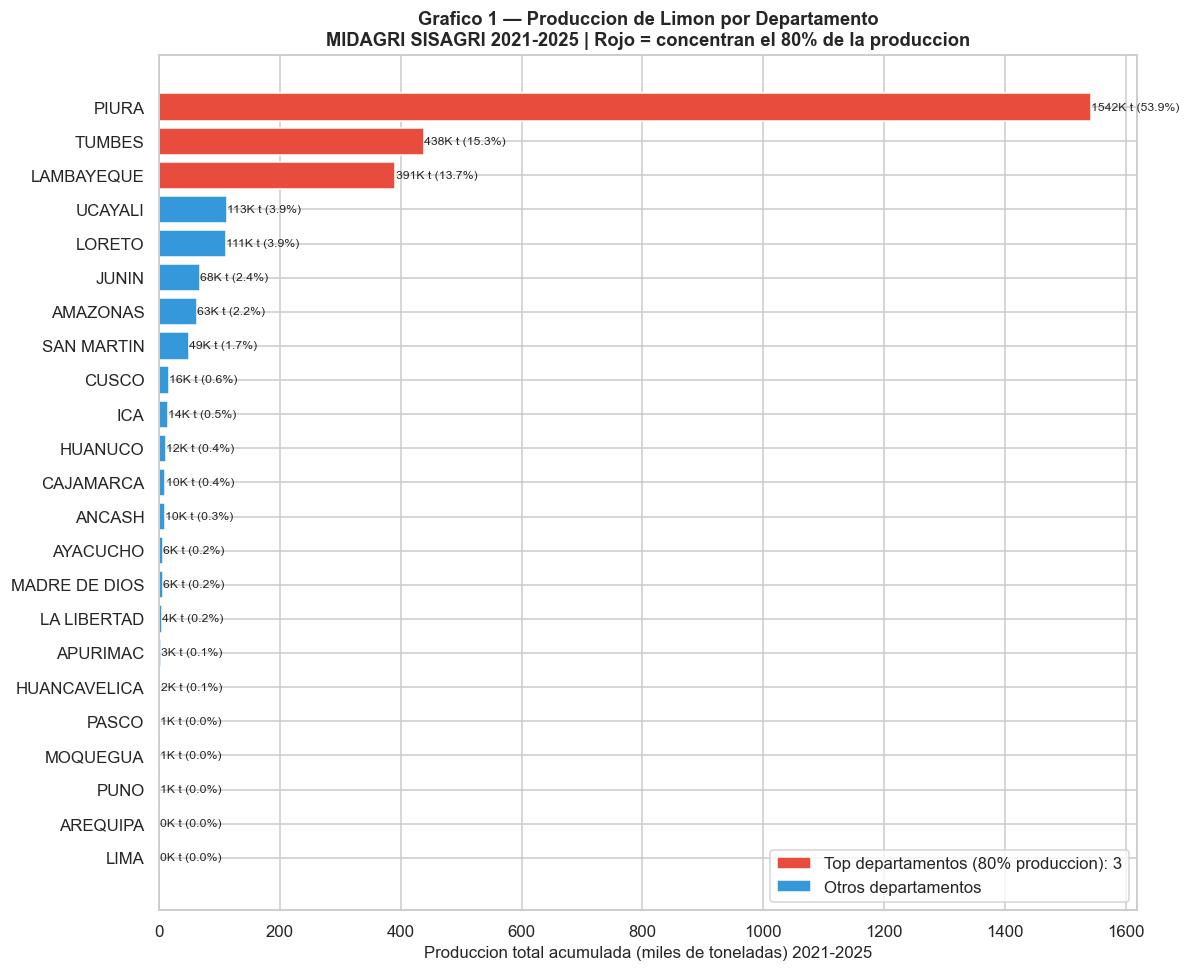

Guardado: pipeline/output/03_eda/act03_midagri_g1_prod_dpto.png


In [3]:
prod_dpto = df_limon.groupby('Dpto')['PRODUCCION(t)'].sum().sort_values(ascending=False)
total = prod_dpto.sum()
# Regla de Pareto: departamentos que acumulan el 80%
acum, dptos_80 = 0, []
for d, v in prod_dpto.items():
    acum += v / total * 100
    dptos_80.append(d)
    if acum >= 80: break
print(f'Departamentos que concentran el 80% de la produccion ({len(dptos_80)}): {dptos_80}')
print(f'Porcentaje acumulado: {acum:.1f}%')
print()

prod_plot = prod_dpto.sort_values(ascending=True)
colors_g1 = ['#e74c3c' if d in dptos_80 else '#3498db' for d in prod_plot.index]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(prod_plot.index, prod_plot.values/1e3, color=colors_g1, edgecolor='white')
for bar, val in zip(bars, prod_plot.values):
    pct = val/total*100
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{val/1e3:.0f}K t ({pct:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Produccion total acumulada (miles de toneladas) 2021-2025', fontsize=11)
ax.set_title('Grafico 1 — Produccion de Limon por Departamento\n'
             'MIDAGRI SISAGRI 2021-2025 | Rojo = concentran el 80% de la produccion',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label=f'Top departamentos (80% produccion): {len(dptos_80)}'),
    Patch(facecolor='#3498db', label='Otros departamentos')
], loc='lower right')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g1_prod_dpto.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** El ranking de produccion de limon por departamento 2021-2025. Los departamentos en rojo concentran el 80% de la produccion nacional (regla de Pareto).

**Implicacion para el pipeline:** El modelo se entrenara priorizando estos departamentos. Los de produccion marginal pueden generar ruido y se evaluara su inclusion en la Actividad 5.

**Implicacion para el modelo:** Concentrar el entrenamiento en los departamentos de mayor produccion garantiza que el LSTM-Attention aprenda patrones representativos del mercado nacional de limon.


## Grafico 2 — Serie temporal de produccion mensual


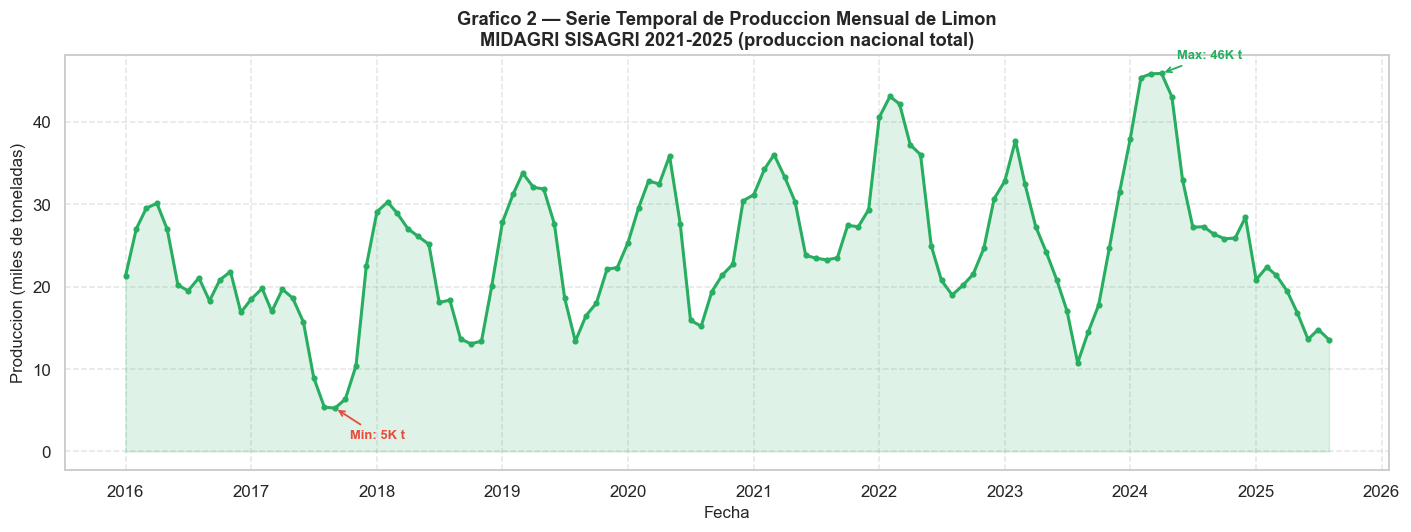

Guardado: pipeline/output/03_eda/act03_midagri_g2_serie_temporal.png
Produccion media mensual: 24.7K t
Coeficiente de variacion: 35.0%


In [4]:
serie = prod_mensual.sort_values('fecha_mes')
idx_max = serie['produccion_t'].idxmax()
idx_min = serie['produccion_t'].idxmin()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie['fecha_mes'], serie['produccion_t']/1e3,
        color='#27ae60', linewidth=2, marker='o', markersize=3)
ax.fill_between(serie['fecha_mes'], serie['produccion_t']/1e3, alpha=0.15, color='#27ae60')
ax.annotate(f'Max: {serie.loc[idx_max,"produccion_t"]/1e3:.0f}K t',
            xy=(serie.loc[idx_max,'fecha_mes'], serie.loc[idx_max,'produccion_t']/1e3),
            xytext=(10,10), textcoords='offset points', fontsize=8.5,
            color='#27ae60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))
ax.annotate(f'Min: {serie.loc[idx_min,"produccion_t"]/1e3:.0f}K t',
            xy=(serie.loc[idx_min,'fecha_mes'], serie.loc[idx_min,'produccion_t']/1e3),
            xytext=(10,-20), textcoords='offset points', fontsize=8.5,
            color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Produccion (miles de toneladas)', fontsize=11)
ax.set_title('Grafico 2 — Serie Temporal de Produccion Mensual de Limon\n'
             'MIDAGRI SISAGRI 2021-2025 (produccion nacional total)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g2_serie_temporal.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Produccion media mensual: {serie["produccion_t"].mean()/1e3:.1f}K t')
print(f'Coeficiente de variacion: {serie["produccion_t"].std()/serie["produccion_t"].mean()*100:.1f}%')


### Interpretacion

**Que muestra:** La evolucion mensual de la produccion total de limon 2021-2025. Se identifican el mes de mayor y menor produccion, tendencia y eventos anomalos.

**Implicacion para el pipeline:** Las caidas bruscas son candidatas a investigar en la Actividad 4. El coeficiente de variacion indica que tan variable es la produccion mes a mes.

**Implicacion para el modelo:** La estacionalidad visible confirma que el LSTM-Attention necesita capturar patrones temporales ciclicos. Esta es la variable objetivo del modelo.


## Grafico 3 — Distribucion de precios en chacra


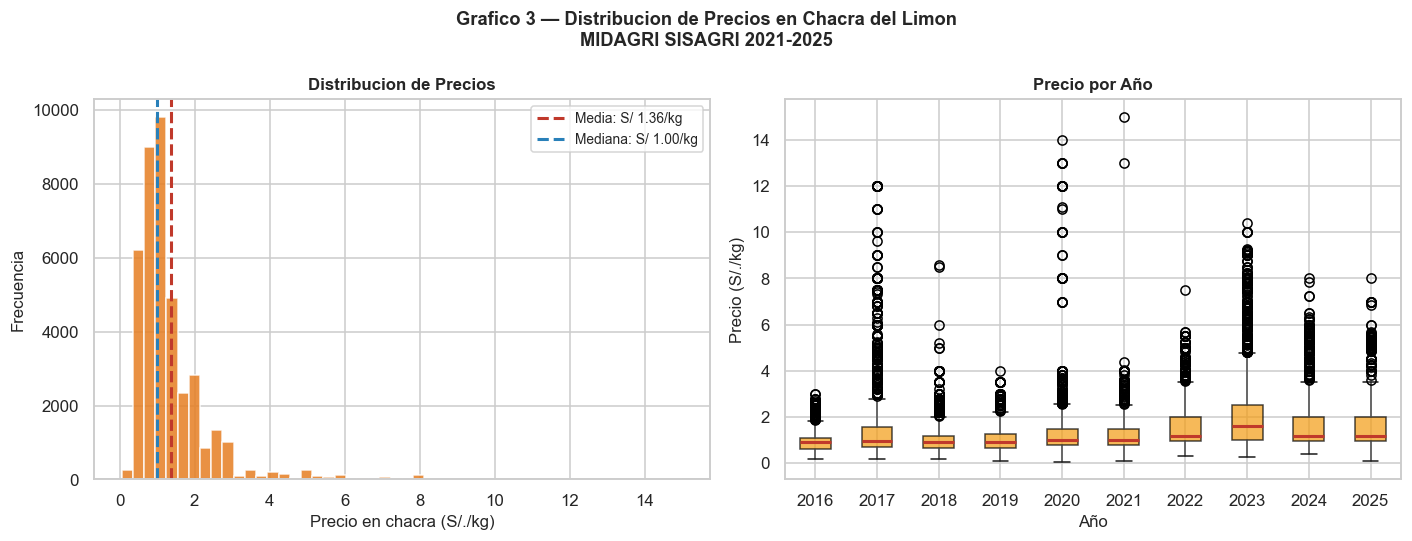

Guardado: pipeline/output/03_eda/act03_midagri_g3_precio_dist.png
Precio medio: S/ 1.36/kg | Mediana: S/ 1.00/kg
Outliers extremos (>P99 = S/6.00): 389 registros


In [5]:
precios = df_limon['MTO_PRECCHAC (S/ x kg)'].dropna()
precios = precios[precios > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(precios, bins=50, color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].axvline(precios.mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media: S/ {precios.mean():.2f}/kg')
axes[0].axvline(precios.median(), color='#2980b9', linestyle='--', linewidth=2,
                label=f'Mediana: S/ {precios.median():.2f}/kg')
axes[0].set_xlabel('Precio en chacra (S/./kg)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de Precios', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

df_limon['anho_str'] = df_limon['anho'].astype(str)
df_limon[df_limon['MTO_PRECCHAC (S/ x kg)'] > 0].boxplot(
    column='MTO_PRECCHAC (S/ x kg)', by='anho_str', ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='#f39c12', alpha=0.7),
    medianprops=dict(color='#c0392b', linewidth=2)
)
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Precio (S/./kg)', fontsize=11)
axes[1].set_title('Precio por Año', fontsize=11, fontweight='bold')
plt.suptitle('Grafico 3 — Distribucion de Precios en Chacra del Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g3_precio_dist.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
q99 = precios.quantile(0.99)
print(f'Precio medio: S/ {precios.mean():.2f}/kg | Mediana: S/ {precios.median():.2f}/kg')
print(f'Outliers extremos (>P99 = S/{q99:.2f}): {(precios > q99).sum()} registros')


### Interpretacion

**Que muestra:** La distribucion del precio en chacra del limon. Si la media es mayor que la mediana, la distribucion esta sesgada a la derecha.

**Implicacion para el pipeline:** Los precios extremos se trataran en la Actividad 5 con IQR. El boxplot por año muestra si los precios han subido o bajado en el periodo.

**Implicacion para el modelo:** Una distribucion muy sesgada requiere transformacion (log o escalado robusto) para que el modelo no sea dominado por valores extremos.


## Grafico 4 — Correlacion produccion vs precio


Correlacion de Pearson produccion vs precio: -0.304


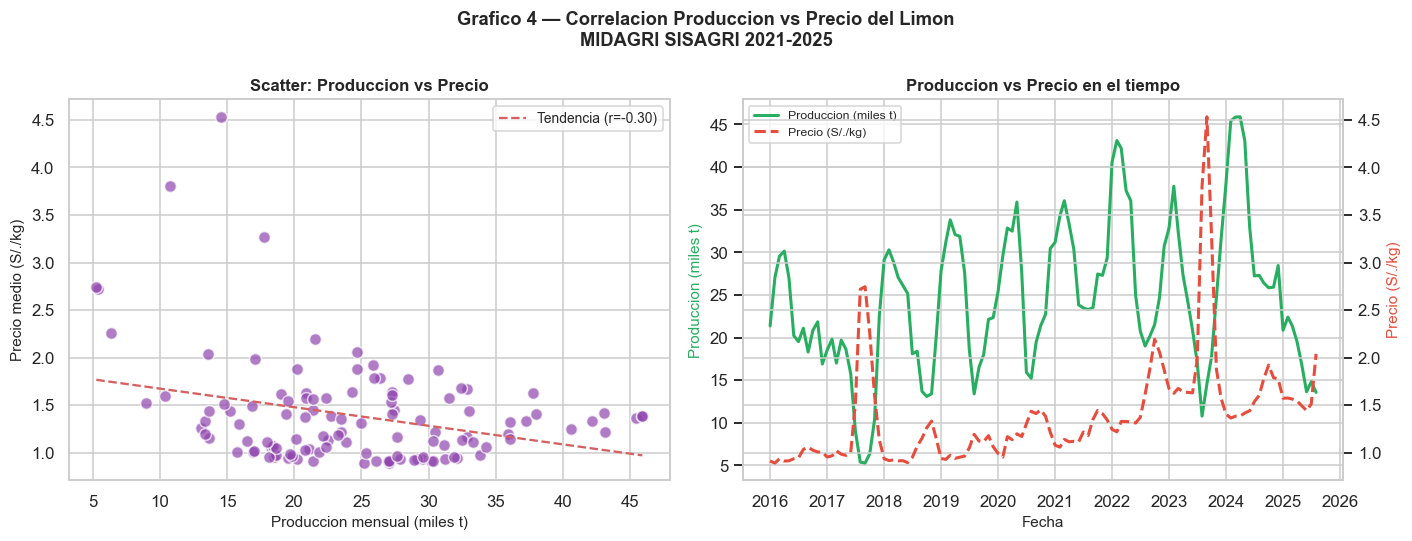

Guardado: pipeline/output/03_eda/act03_midagri_g4_prod_vs_precio.png


In [6]:
mensual = prod_mensual[prod_mensual['precio_kg'] > 0].copy()
corr = mensual['produccion_t'].corr(mensual['precio_kg'])
print(f'Correlacion de Pearson produccion vs precio: {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(mensual['produccion_t']/1e3, mensual['precio_kg'],
                alpha=0.7, color='#8e44ad', edgecolors='white', s=60)
z = np.polyfit(mensual['produccion_t']/1e3, mensual['precio_kg'], 1)
p = np.poly1d(z)
x_line = np.linspace(mensual['produccion_t'].min()/1e3, mensual['produccion_t'].max()/1e3, 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=1.5, label=f'Tendencia (r={corr:.2f})')
axes[0].set_xlabel('Produccion mensual (miles t)', fontsize=10)
axes[0].set_ylabel('Precio medio (S/./kg)', fontsize=10)
axes[0].set_title('Scatter: Produccion vs Precio', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

ax2 = axes[1].twinx()
axes[1].plot(mensual['fecha_mes'], mensual['produccion_t']/1e3,
             color='#27ae60', linewidth=2, label='Produccion (miles t)')
ax2.plot(mensual['fecha_mes'], mensual['precio_kg'],
         color='#e74c3c', linewidth=2, linestyle='--', label='Precio (S/./kg)')
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('Produccion (miles t)', fontsize=10, color='#27ae60')
ax2.set_ylabel('Precio (S/./kg)', fontsize=10, color='#e74c3c')
axes[1].set_title('Produccion vs Precio en el tiempo', fontsize=11, fontweight='bold')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')
plt.suptitle('Grafico 4 — Correlacion Produccion vs Precio del Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g4_prod_vs_precio.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La relacion entre produccion mensual y precio en chacra. Una correlacion negativa confirma la ley de oferta/demanda.

**Implicacion para el pipeline:** Si la correlacion es fuerte (|r| > 0.5), incluir el precio puede generar multicolinealidad con la variable objetivo. Se evaluara en la Actividad 9.

**Implicacion para el modelo:** El LSTM-Attention puede aprender esta relacion implicita si se incluyen ambas variables como entrada.


## Grafico 5 — Estacionalidad mensual de la produccion


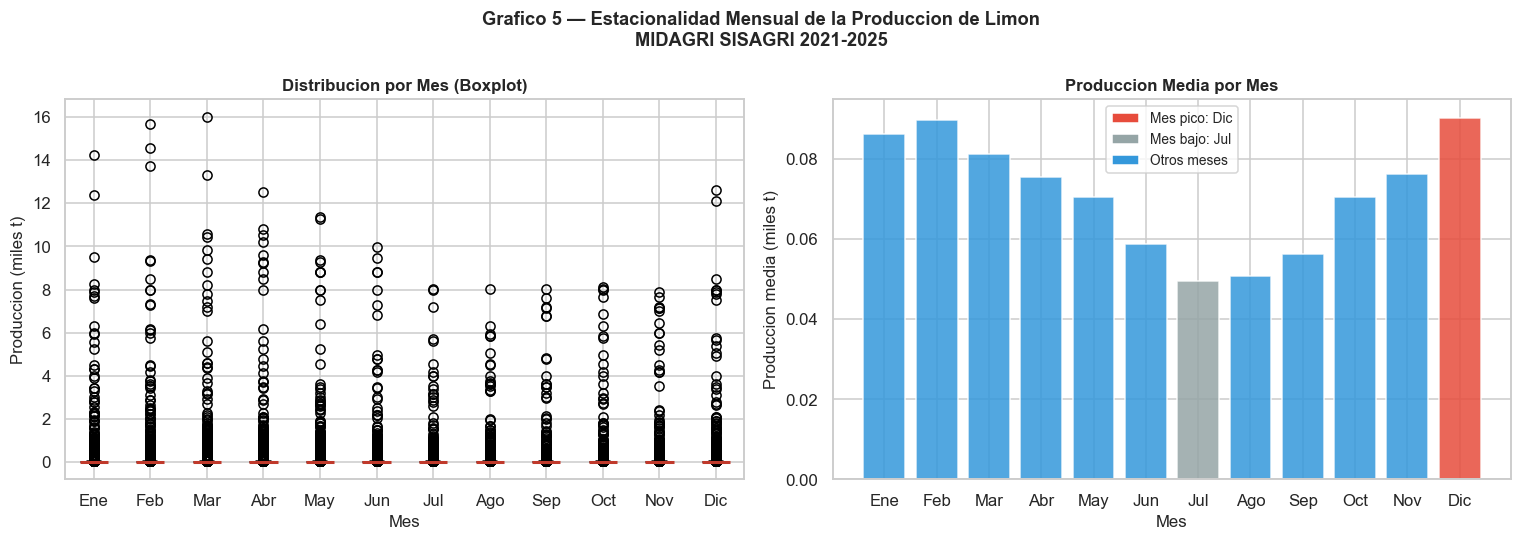

Guardado: pipeline/output/03_eda/act03_midagri_g5_estacionalidad.png
Mes de mayor produccion: Dic (mes 12)
Mes de menor produccion: Jul (mes 7)


In [7]:
df_limon['mes_num'] = df_limon['mes'].astype(int)
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_bp = [df_limon[df_limon['mes_num']==m]['PRODUCCION(t)'].values/1e3 for m in range(1,13)]
bp = axes[0].boxplot(data_bp, labels=meses_nombres, patch_artist=True,
                     medianprops=dict(color='#c0392b', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#3498db'); patch.set_alpha(0.6)
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Produccion (miles t)', fontsize=11)
axes[0].set_title('Distribucion por Mes (Boxplot)', fontsize=11, fontweight='bold')

media_mes = df_limon.groupby('mes_num')['PRODUCCION(t)'].mean()/1e3
mes_max = media_mes.idxmax()
mes_min = media_mes.idxmin()
colors_mes = ['#e74c3c' if m==mes_max else '#95a5a6' if m==mes_min else '#3498db' for m in range(1,13)]
axes[1].bar(range(1,13), [media_mes.get(m,0) for m in range(1,13)],
            color=colors_mes, edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses_nombres)
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Produccion media (miles t)', fontsize=11)
axes[1].set_title('Produccion Media por Mes', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#e74c3c', label=f'Mes pico: {meses_nombres[mes_max-1]}'),
    Patch(facecolor='#95a5a6', label=f'Mes bajo: {meses_nombres[mes_min-1]}'),
    Patch(facecolor='#3498db', label='Otros meses')
], fontsize=9)
plt.suptitle('Grafico 5 — Estacionalidad Mensual de la Produccion de Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g5_estacionalidad.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Mes de mayor produccion: {meses_nombres[mes_max-1]} (mes {mes_max})')
print(f'Mes de menor produccion: {meses_nombres[mes_min-1]} (mes {mes_min})')


### Interpretacion

**Que muestra:** El patron estacional de la produccion de limon. El boxplot muestra la variabilidad dentro de cada mes entre diferentes años.

**Implicacion para el pipeline:** El mes de mayor y menor produccion son puntos de referencia para validar el modelo. La estacionalidad justifica incluir variables ciclicas (month_sin/cos) en Fase 2.

**Implicacion para el modelo:** Un modelo que no capture la estacionalidad cometera errores sistematicos en los meses de pico y valle. El LSTM-Attention aprendera este patron de la secuencia.


---
# 2. EDA — INDECI

Analisis de emergencias hidrometeorologicas y su relacion con la produccion de limon.


## Grafico 6 — Fenomenos hidrometeorologicos por frecuencia


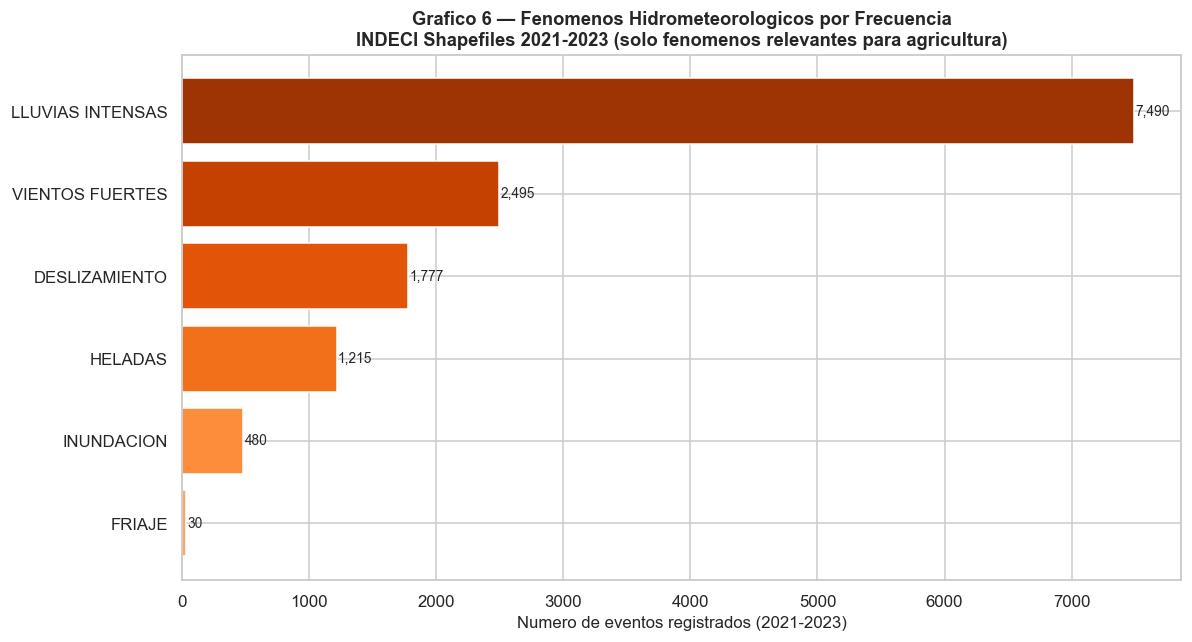

Guardado: pipeline/output/03_eda/act03_indeci_g1_fenomenos.png
Top 5 fenomenos:
fenomeno
INUNDACION           480
HELADAS             1215
DESLIZAMIENTO       1777
VIENTOS FUERTES     2495
LLUVIAS INTENSAS    7490


In [8]:
fen_counts = df_agro['fenomeno'].str.upper().value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors_fen = plt.cm.Oranges(np.linspace(0.4, 0.9, len(fen_counts)))
bars = ax.barh(fen_counts.index, fen_counts.values, color=colors_fen, edgecolor='white')
for bar, val in zip(bars, fen_counts.values):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Numero de eventos registrados (2021-2023)', fontsize=11)
ax.set_title('Grafico 6 — Fenomenos Hidrometeorologicos por Frecuencia\n'
             'INDECI Shapefiles 2021-2023 (solo fenomenos relevantes para agricultura)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_indeci_g1_fenomenos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print('Top 5 fenomenos:')
print(fen_counts.tail(5).to_string())


### Interpretacion

**Que muestra:** La frecuencia de cada tipo de fenomeno hidrometeorologico relevante para agricultura.

**Implicacion para el pipeline:** En la Actividad 5 se filtrara el dataset INDECI conservando solo estos fenomenos. La distribucion justifica que el conteo mensual es informativo.

**Implicacion para el modelo:** Los fenomenos mas frecuentes (lluvias intensas, huaycos) son los que mas variabilidad aportan a la variable `num_emergencias`.


## Grafico 7 — Emergencias por departamento productor de limon


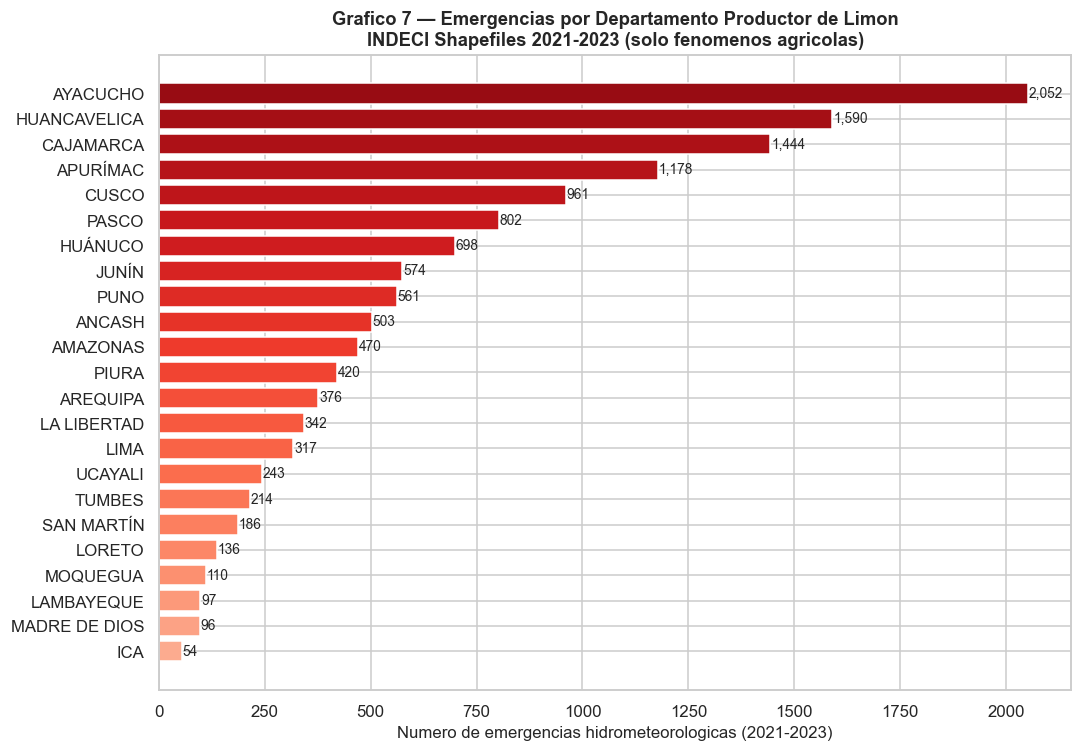

Guardado: pipeline/output/03_eda/act03_indeci_g2_dpto.png


In [9]:
dptos_limon = set(normalizar(d) for d in df_limon['Dpto'].dropna().unique())
df_agro['dpto_norm'] = df_agro['departamen'].apply(normalizar)
df_limon_indeci = df_agro[df_agro['dpto_norm'].isin(dptos_limon)]
emer_dpto = df_limon_indeci['departamen'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_d = plt.cm.Reds(np.linspace(0.3, 0.9, len(emer_dpto)))
bars = ax.barh(emer_dpto.index, emer_dpto.values, color=colors_d, edgecolor='white')
for bar, val in zip(bars, emer_dpto.values):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Numero de emergencias hidrometeorologicas (2021-2023)', fontsize=11)
ax.set_title('Grafico 7 — Emergencias por Departamento Productor de Limon\n'
             'INDECI Shapefiles 2021-2023 (solo fenomenos agricolas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_indeci_g2_dpto.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de emergencias en los departamentos productores de limon.

**Implicacion para el pipeline:** Los departamentos con pocas emergencias tendran `num_emergencias` cercana a cero en muchos meses, lo que puede reducir su poder predictivo.

**Implicacion para el modelo:** La variabilidad geografica de las emergencias es lo que hace que esta variable sea informativa para el LSTM-Attention.


## Grafico 8 — Serie temporal de emergencias mensuales


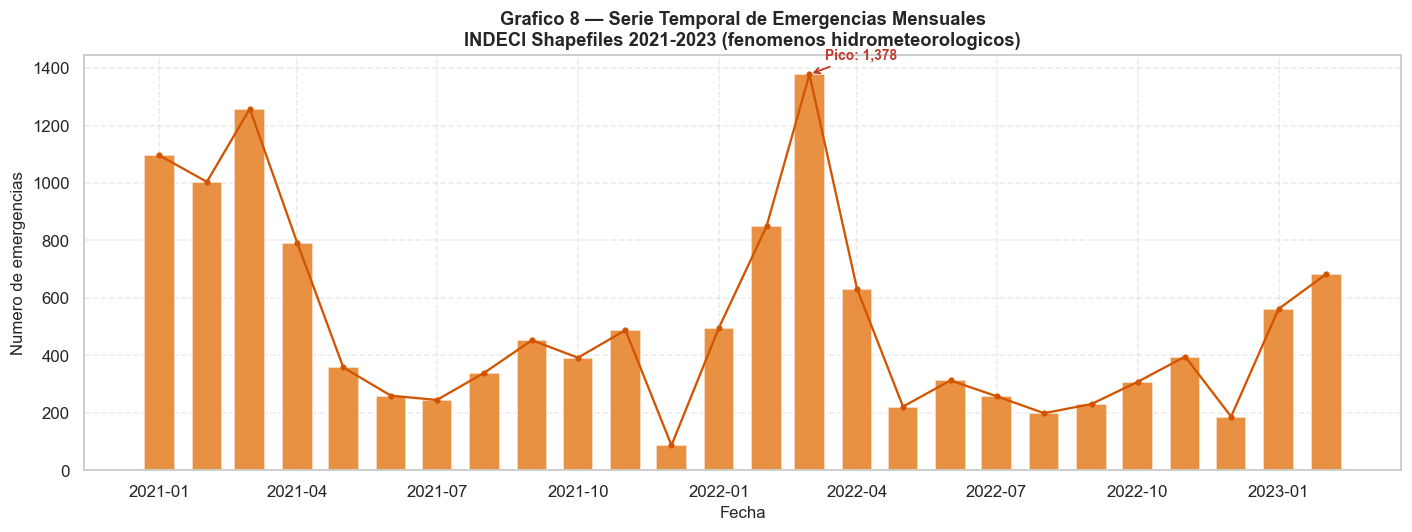

Guardado: pipeline/output/03_eda/act03_indeci_g3_serie.png


In [10]:
serie_emer = emer_mensual.sort_values('fecha_mes').dropna(subset=['fecha_mes'])

if len(serie_emer) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(serie_emer['fecha_mes'], serie_emer['n_emergencias'],
           color='#e67e22', edgecolor='white', width=20, alpha=0.85)
    ax.plot(serie_emer['fecha_mes'], serie_emer['n_emergencias'],
            color='#d35400', linewidth=1.5, marker='o', markersize=3)
    idx_pico = serie_emer['n_emergencias'].idxmax()
    ax.annotate(f'Pico: {serie_emer.loc[idx_pico,"n_emergencias"]:,}',
                xy=(serie_emer.loc[idx_pico,'fecha_mes'], serie_emer.loc[idx_pico,'n_emergencias']),
                xytext=(10,10), textcoords='offset points', fontsize=9,
                color='#c0392b', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Numero de emergencias', fontsize=11)
    ax.set_title('Grafico 8 — Serie Temporal de Emergencias Mensuales\n'
                 'INDECI Shapefiles 2021-2023 (fenomenos hidrometeorologicos)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_indeci_g3_serie.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
else:
    print('Sin datos de emergencias con fecha valida.')


### Interpretacion

**Que muestra:** La evolucion mensual del numero de emergencias. Los picos estacionales (dic-mar, temporada de lluvias) son visibles.

**Implicacion para el pipeline:** La serie debe alinearse con la produccion de limon para el merge en la Actividad 6. Los meses sin emergencias tendran valor 0.

**Implicacion para el modelo:** Si los picos de emergencias preceden a las caidas de produccion por 1-2 meses, la variable con rezagos temporales sera especialmente informativa.


## Grafico 9 — Emergencias vs produccion de limon


Correlacion emergencias vs produccion: 0.657
Meses en comun: 26


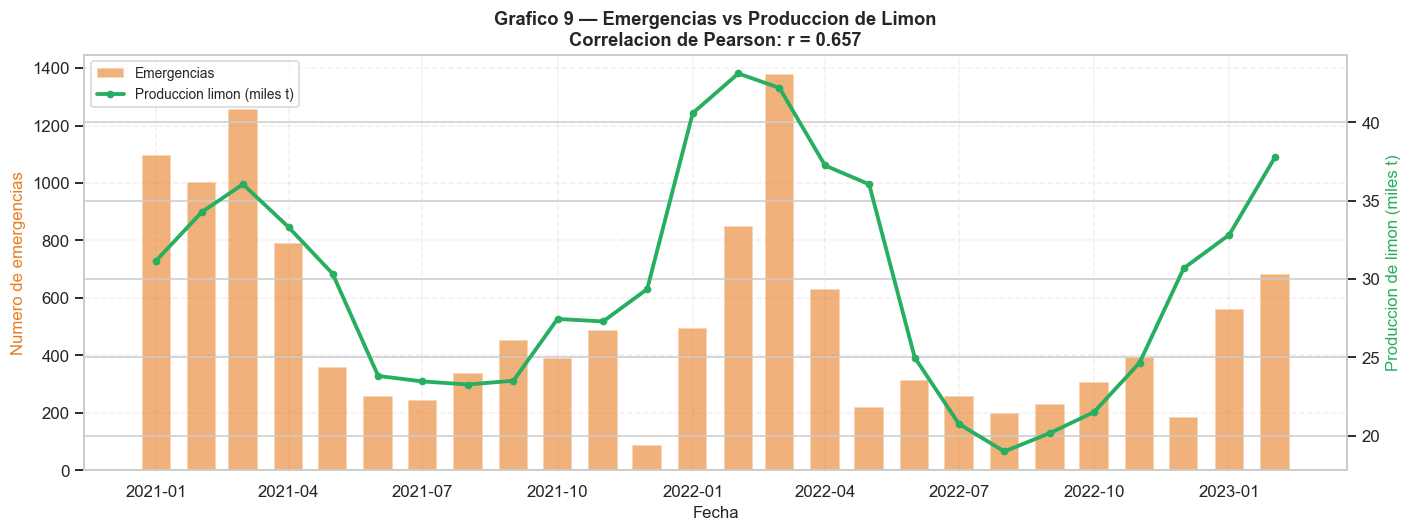

Guardado: pipeline/output/03_eda/act03_indeci_g4_vs_produccion.png


In [11]:
df_comp = pd.merge(serie_emer, prod_mensual, on='fecha_mes', how='inner')

if len(df_comp) > 0:
    corr_ep = df_comp['n_emergencias'].corr(df_comp['produccion_t'])
    print(f'Correlacion emergencias vs produccion: {corr_ep:.3f}')
    print(f'Meses en comun: {len(df_comp)}')

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax2 = ax1.twinx()
    ax1.bar(df_comp['fecha_mes'], df_comp['n_emergencias'],
            color='#e67e22', alpha=0.6, width=20, label='Emergencias')
    ax2.plot(df_comp['fecha_mes'], df_comp['produccion_t']/1e3,
             color='#27ae60', linewidth=2.5, marker='o', markersize=4,
             label='Produccion limon (miles t)')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Numero de emergencias', fontsize=11, color='#e67e22')
    ax2.set_ylabel('Produccion de limon (miles t)', fontsize=11, color='#27ae60')
    ax1.set_title(f'Grafico 9 — Emergencias vs Produccion de Limon\n'
                  f'Correlacion de Pearson: r = {corr_ep:.3f}',
                  fontsize=12, fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_indeci_g4_vs_produccion.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
else:
    print('Sin meses en comun entre INDECI y MIDAGRI.')


### Interpretacion

**Que muestra:** La relacion temporal entre emergencias y produccion de limon. Una correlacion negativa confirma que las emergencias impactan negativamente la produccion.

**Implicacion para el pipeline:** Este grafico es la justificacion principal para incluir INDECI en el dataset maestro. Una correlacion negativa significativa (r < -0.3) confirma que las emergencias tienen impacto real en la produccion.

**Implicacion para el modelo:** Si la correlacion es debil en el mismo mes, puede ser mas fuerte con un rezago de 1-2 meses. Esto se explorara en la Actividad 9.


---
# 3. EDA — NASA POWER

Analisis de las 8 variables climaticas, identificacion de redundancias y justificacion de cuales son mas relevantes para predecir la produccion de limon.


## Grafico 10 — Distribuciones de las 8 variables climaticas


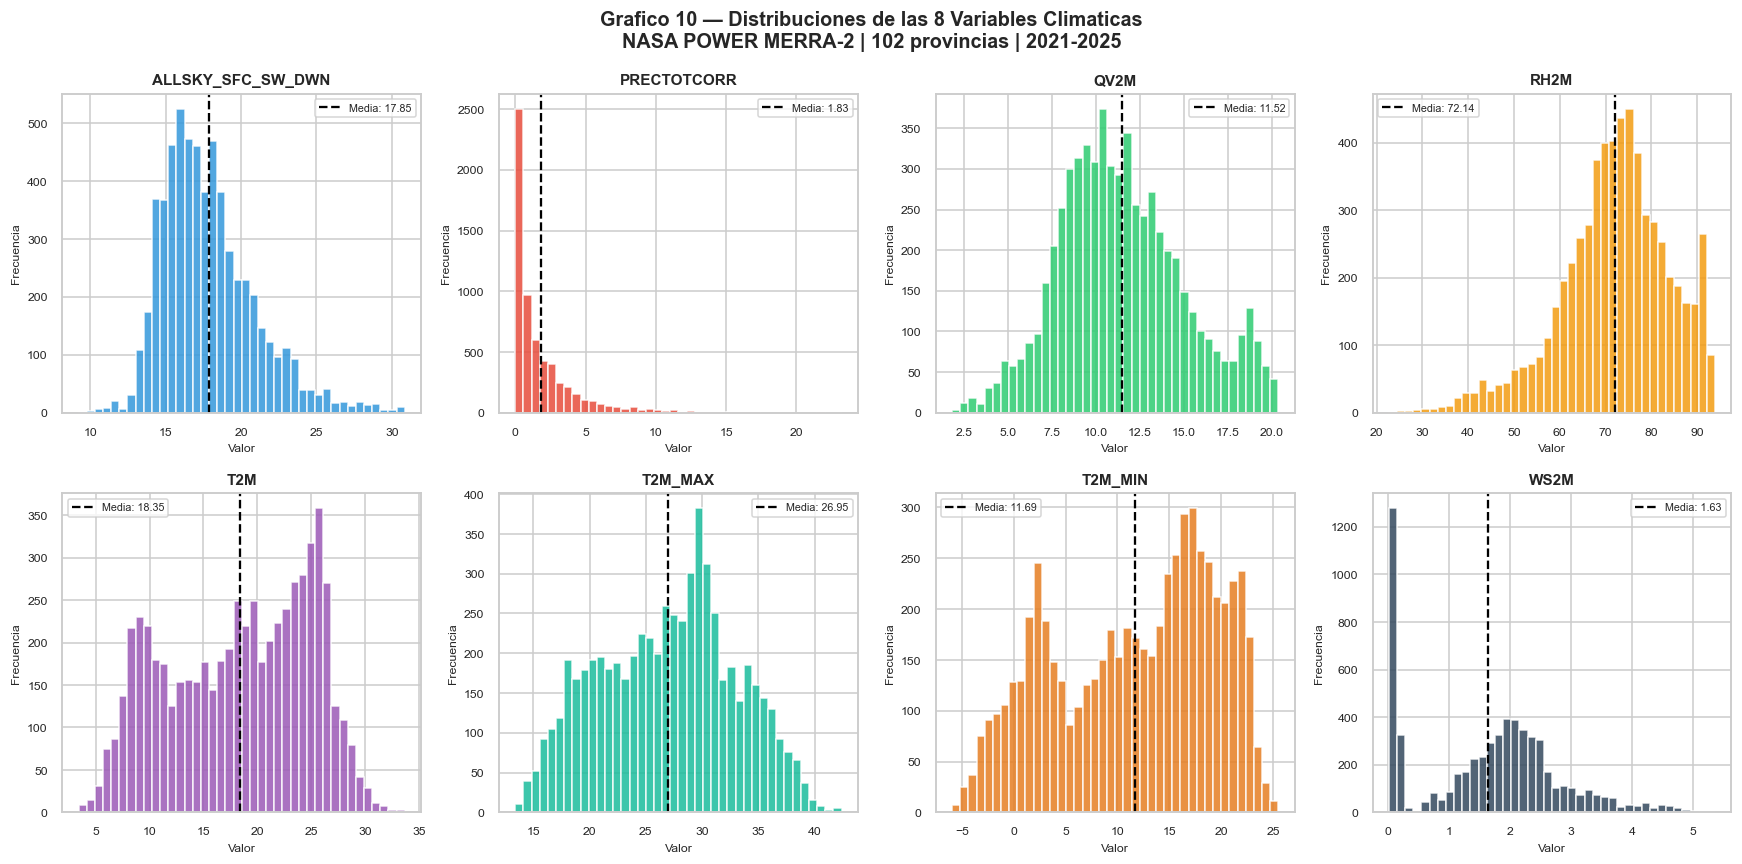

Guardado: pipeline/output/03_eda/act03_nasa_g1_distribuciones.png


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colores_hist = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

for i, (var, color) in enumerate(zip(VARS_CLIMA, colores_hist)):
    data = df_nasa[var].dropna()
    axes[i].hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Grafico 10 — Distribuciones de las 8 Variables Climaticas\n'
             'NASA POWER MERRA-2 | 102 provincias | 2021-2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g1_distribuciones.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de cada variable climatica en las 102 provincias. Distribuciones bimodales indican dos grupos de provincias con climas muy diferentes (costa vs sierra).

**Implicacion para el pipeline:** Variables con distribuciones muy sesgadas pueden requerir transformacion logaritmica antes del escalado en la Actividad 9.

**Implicacion para el modelo:** El StandardScaler asume distribuciones aproximadamente normales. Variables muy sesgadas pueden degradar el rendimiento del LSTM-Attention.


## Grafico 11 — Series temporales climaticas para provincias clave


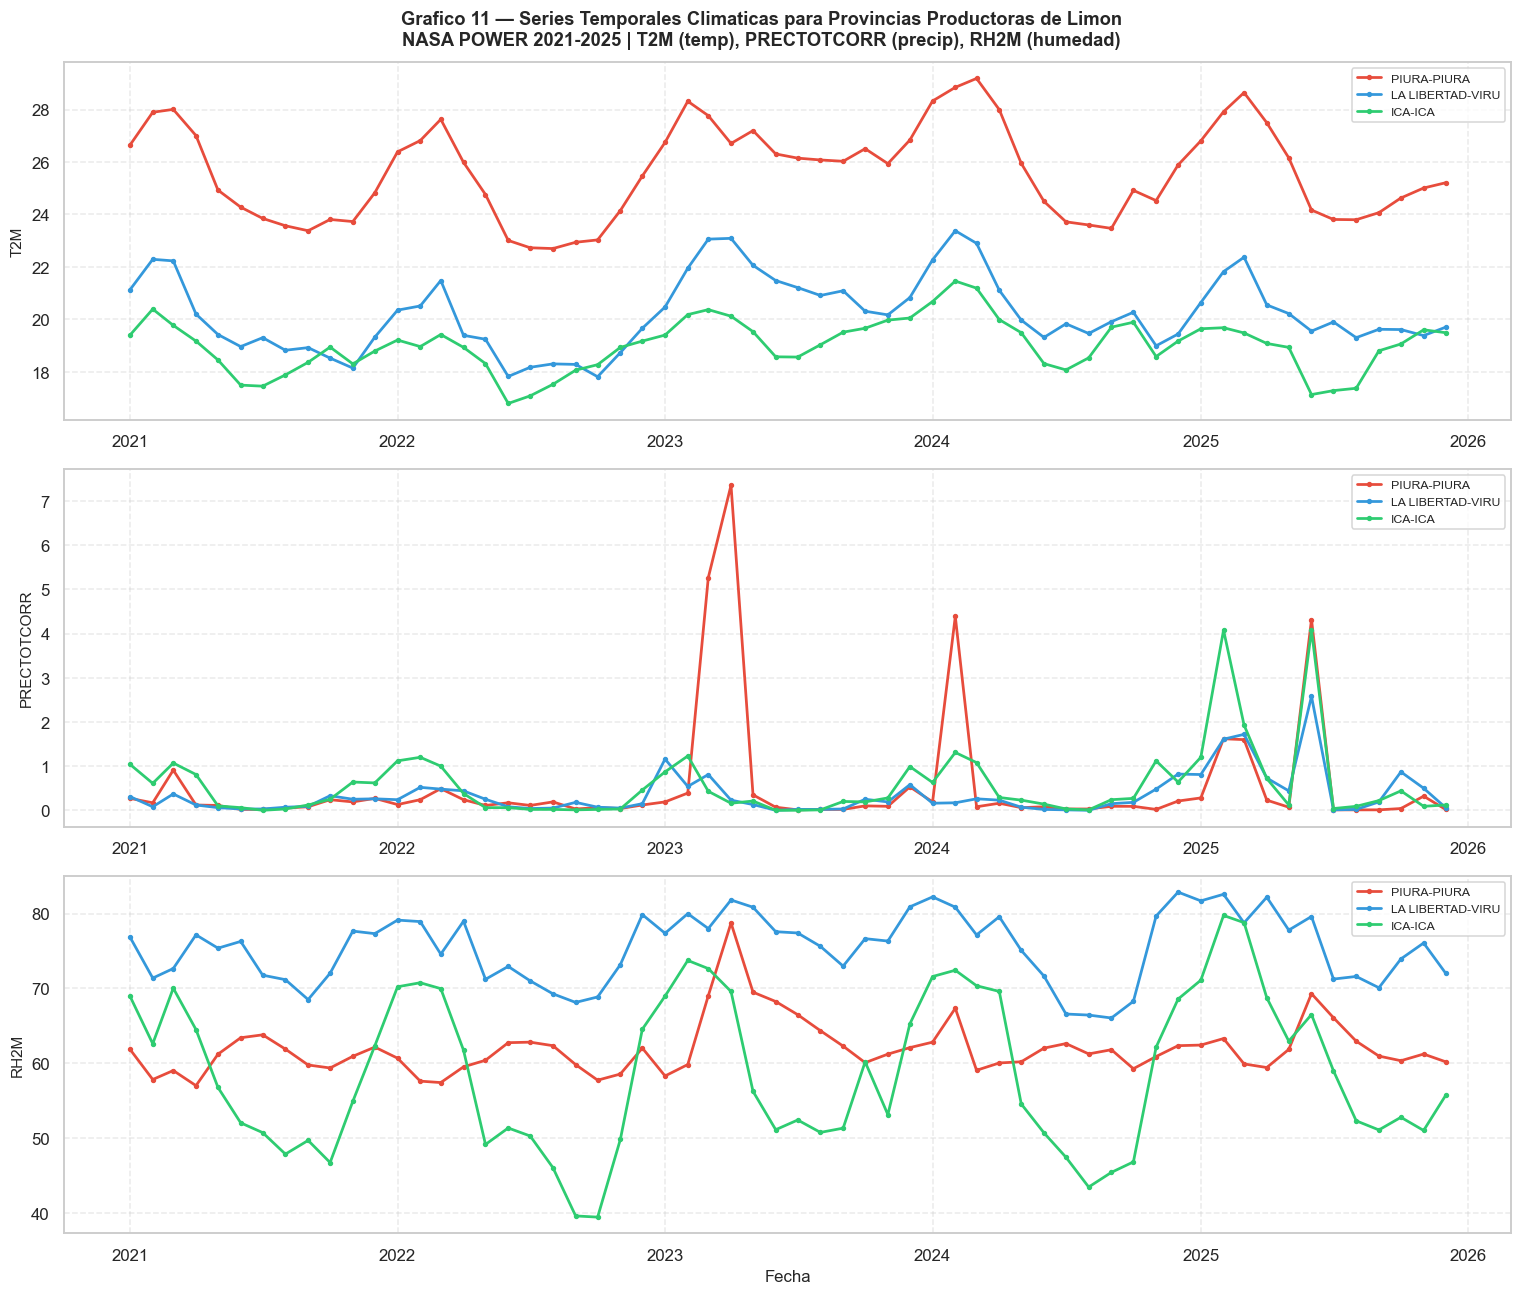

Guardado: pipeline/output/03_eda/act03_nasa_g2_series.png


In [13]:
provincias_clave = [('PIURA','PIURA'), ('LA LIBERTAD','VIRU'), ('ICA','ICA')]
vars_plot = ['T2M', 'PRECTOTCORR', 'RH2M']
colores_prov = ['#e74c3c','#3498db','#2ecc71']
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(len(vars_plot), 1, figsize=(14, 12))
for ax, var in zip(axes, vars_plot):
    for (dpto, prov), color in zip(provincias_clave, colores_prov):
        mask = ((df_nasa['DEPARTAMENTO'].str.upper()==dpto) &
                (df_nasa['PROVINCIA'].str.upper()==prov))
        df_sub = df_nasa[mask].sort_values(['YEAR','MES']).copy()
        if df_sub.empty or var not in df_sub.columns: continue
        df_sub['fecha'] = pd.to_datetime(
            df_sub['YEAR'].astype(str)+'-'+df_sub['MES'].astype(str).str.zfill(2)+'-01')
        ax.plot(df_sub['fecha'], df_sub[var], color=color, linewidth=1.8,
                marker='o', markersize=2.5, label=f'{dpto}-{prov}')
    ax.set_ylabel(var, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
axes[-1].set_xlabel('Fecha', fontsize=11)
plt.suptitle('Grafico 11 — Series Temporales Climaticas para Provincias Productoras de Limon\n'
             'NASA POWER 2021-2025 | T2M (temp), PRECTOTCORR (precip), RH2M (humedad)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g2_series.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La evolucion mensual de temperatura, precipitacion y humedad en las tres principales zonas productoras de limon.

**Implicacion para el pipeline:** Las anomalias climaticas en 2023 deben correlacionar con los datos de INDECI (mas emergencias) y MIDAGRI (menos produccion). Esta triangulacion valida la coherencia entre las 3 fuentes.

**Implicacion para el modelo:** La estacionalidad climatica confirma que las variables NASA tienen patrones temporales que el LSTM-Attention puede aprender.


## Grafico 12 — Correlacion entre variables climaticas


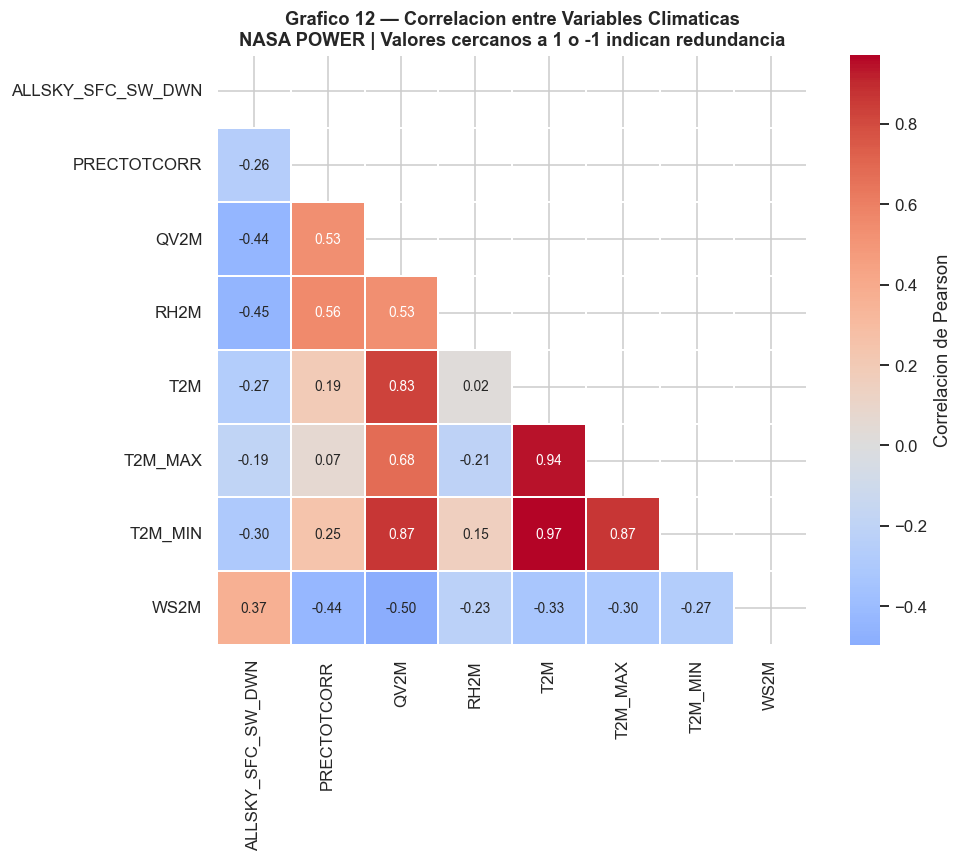

Guardado: pipeline/output/03_eda/act03_nasa_g3_correlacion.png

Pares con alta correlacion (|r| > 0.85):
  QV2M vs T2M_MIN: r = 0.866
  T2M vs T2M_MAX: r = 0.945
  T2M vs T2M_MIN: r = 0.973
  T2M_MAX vs T2M_MIN: r = 0.868


In [14]:
corr_nasa = df_nasa[VARS_CLIMA].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_nasa, dtype=bool))
sns.heatmap(corr_nasa, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 9}, linewidths=0.3)
ax.set_title('Grafico 12 — Correlacion entre Variables Climaticas\n'
             'NASA POWER | Valores cercanos a 1 o -1 indican redundancia',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g3_correlacion.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Pares con alta correlacion (|r| > 0.85):')
for i in range(len(VARS_CLIMA)):
    for j in range(i+1, len(VARS_CLIMA)):
        r = corr_nasa.iloc[i,j]
        if abs(r) > 0.85:
            print(f'  {VARS_CLIMA[i]} vs {VARS_CLIMA[j]}: r = {r:.3f}')


### Interpretacion

**Que muestra:** La correlacion entre las 8 variables climaticas. Pares con |r| > 0.85 son candidatos a redundancia.

**Implicacion para el pipeline:** Las variables altamente correlacionadas se evaluaran para posible descarte en la Actividad 9. Se conservara la que tenga mayor correlacion con la produccion de limon.

**Implicacion para el modelo:** Incluir variables redundantes no mejora la prediccion pero aumenta el tiempo de entrenamiento y el riesgo de sobreajuste.


## Grafico 13 — Correlacion clima vs produccion de limon


Meses en comun clima-produccion: 56


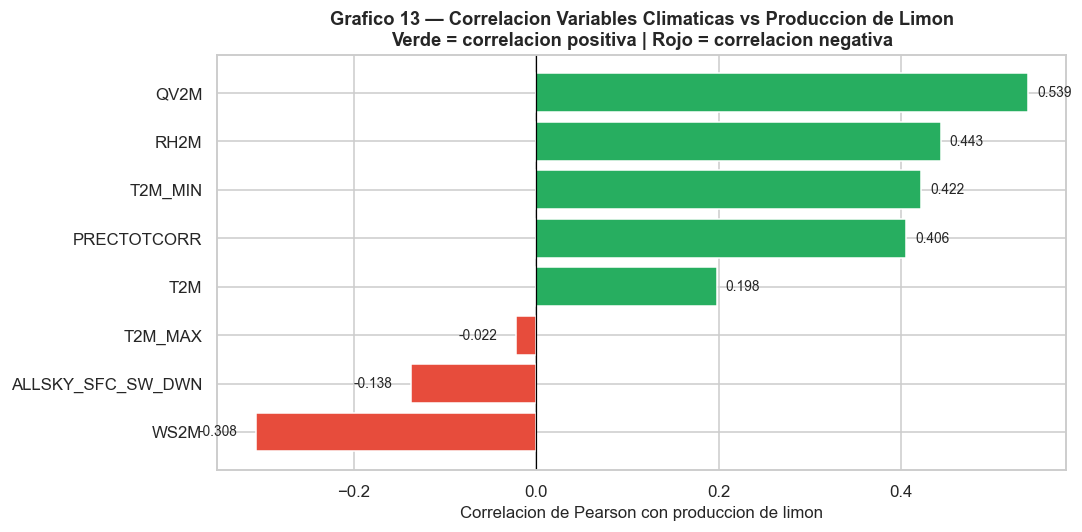

Guardado: pipeline/output/03_eda/act03_nasa_g4_vs_produccion.png
Variable mas correlacionada: QV2M (r=0.539)


In [15]:
prod_anho_mes = df_limon.groupby(['anho','mes'])['PRODUCCION(t)'].sum().reset_index()
prod_anho_mes.columns = ['YEAR','MES','produccion_t']
clima_nacional_ym = df_nasa.groupby(['YEAR','MES'])[VARS_CLIMA].mean().reset_index()
df_merge = pd.merge(clima_nacional_ym, prod_anho_mes, on=['YEAR','MES'], how='inner')
print(f'Meses en comun clima-produccion: {len(df_merge)}')

if len(df_merge) > 5:
    corr_prod = df_merge[VARS_CLIMA+['produccion_t']].corr()['produccion_t'].drop('produccion_t')
    corr_prod = corr_prod.sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_corr = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_prod.values]
    bars = ax.barh(corr_prod.index, corr_prod.values, color=colors_corr, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, corr_prod.values):
        offset = -0.02 if val < 0 else 0.01
        ax.text(val+offset, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9,
                ha='right' if val < 0 else 'left')
    ax.set_xlabel('Correlacion de Pearson con produccion de limon', fontsize=11)
    ax.set_title('Grafico 13 — Correlacion Variables Climaticas vs Produccion de Limon\n'
                 'Verde = correlacion positiva | Rojo = correlacion negativa',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_nasa_g4_vs_produccion.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
    print(f'Variable mas correlacionada: {corr_prod.abs().idxmax()} (r={corr_prod.abs().max():.3f})')


### Interpretacion

**Que muestra:** La correlacion de cada variable climatica con la produccion mensual de limon. Las variables con mayor correlacion absoluta son las mas informativas para el modelo.

**Implicacion para el pipeline:** Las variables con correlacion cercana a 0 son candidatas a descarte en la Actividad 9.

**Implicacion para el modelo:** Este grafico es la justificacion cuantitativa para incluir las variables NASA en el LSTM-Attention. Variables con |r| > 0.3 tienen poder predictivo estadisticamente significativo.


## Grafico 14 — Estacionalidad climatica mensual


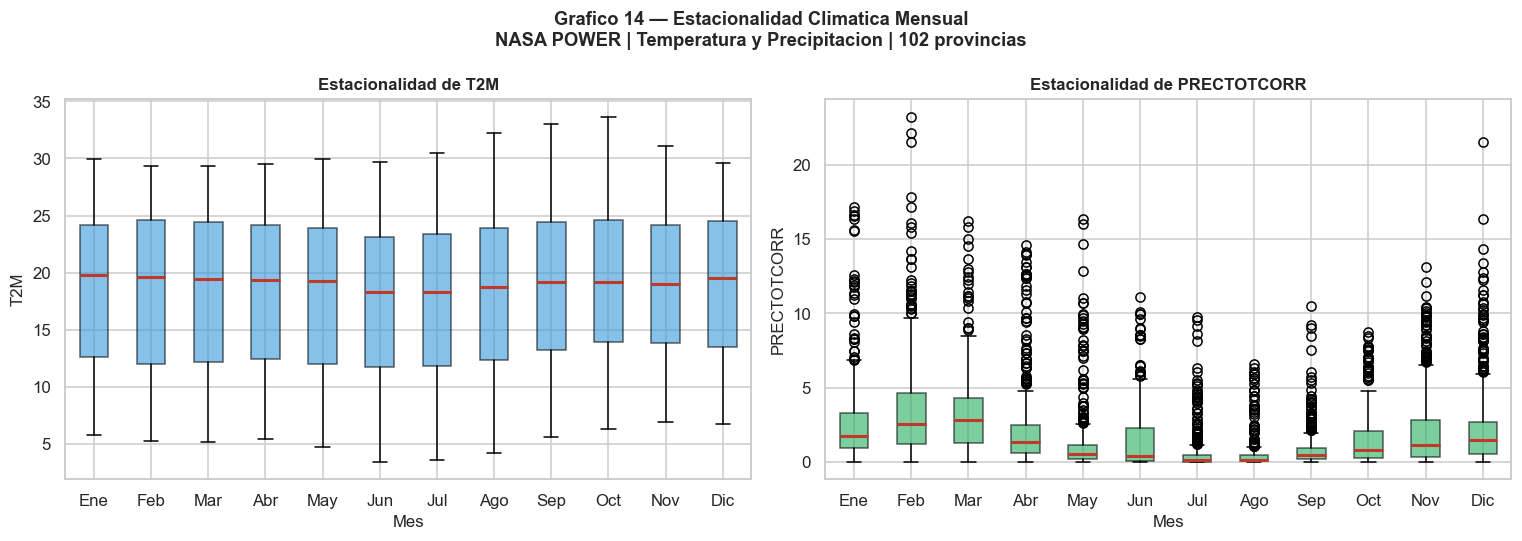

Guardado: pipeline/output/03_eda/act03_nasa_g5_estacionalidad.png


In [16]:
vars_estac = ['T2M', 'PRECTOTCORR']
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var in zip(axes, vars_estac):
    data_mes = [df_nasa[df_nasa['MES']==m][var].dropna().values for m in range(1,13)]
    bp = ax.boxplot(data_mes, labels=meses_nombres, patch_artist=True,
                    medianprops=dict(color='#c0392b', linewidth=2))
    color_box = '#3498db' if var == 'T2M' else '#27ae60'
    for patch in bp['boxes']:
        patch.set_facecolor(color_box); patch.set_alpha(0.6)
    ax.set_xlabel('Mes', fontsize=11)
    ax.set_ylabel(var, fontsize=11)
    ax.set_title(f'Estacionalidad de {var}', fontsize=11, fontweight='bold')
plt.suptitle('Grafico 14 — Estacionalidad Climatica Mensual\n'
             'NASA POWER | Temperatura y Precipitacion | 102 provincias',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g5_estacionalidad.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de temperatura y precipitacion para cada mes del año. Confirma el patron estacional del clima peruano.

**Implicacion para el pipeline:** La estacionalidad clara justifica la codificacion ciclica (month_sin/cos) que se aplicara en la Fase 2.

**Implicacion para el modelo:** El LSTM-Attention puede aprender la estacionalidad de la secuencia temporal, pero la codificacion ciclica explicita acelera el aprendizaje.


---
# 4. EDA — Agraria.pe

Analisis de la cobertura y contenido de las noticias como señal para el modelo.


## Grafico 15 — Noticias por categoria y serie temporal


Correlacion noticias vs produccion: -0.096


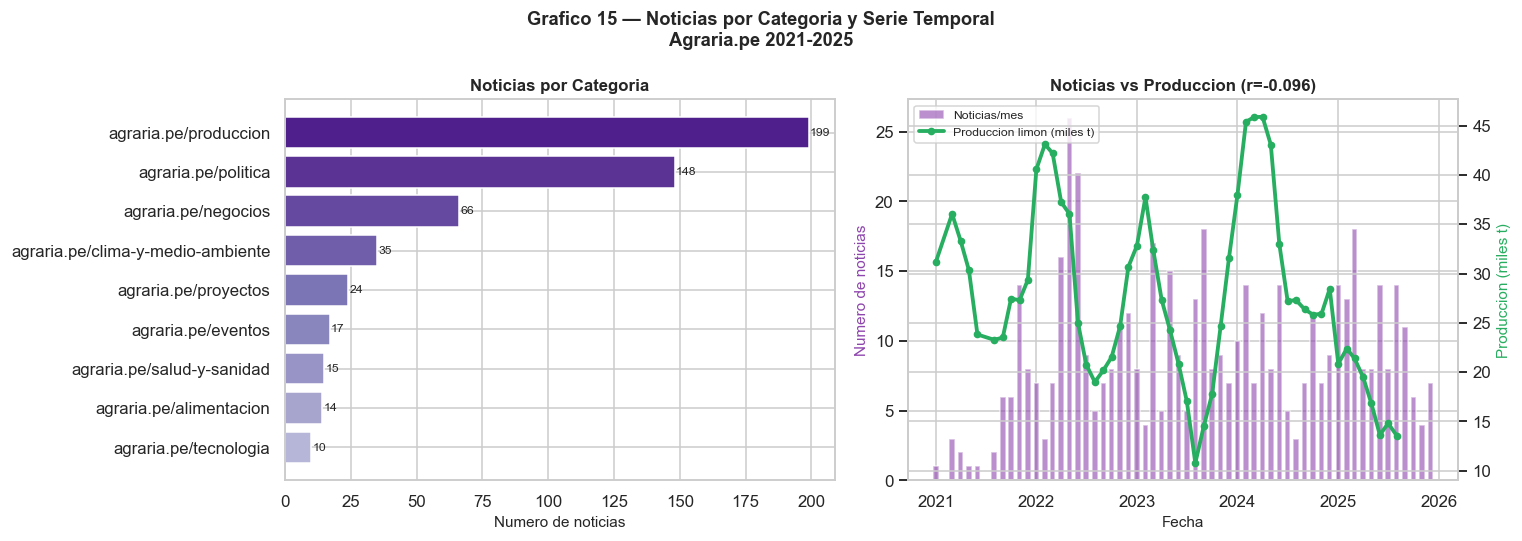

Guardado: pipeline/output/03_eda/act03_agraria_g1_categorias.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: noticias por categoria
if 'fuente' in df_agr.columns:
    cat_counts = df_agr['fuente'].value_counts().sort_values(ascending=True).tail(12)
    colors_cat = plt.cm.Purples(np.linspace(0.4, 0.9, len(cat_counts)))
    axes[0].barh(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
    for i, val in enumerate(cat_counts.values):
        axes[0].text(val+0.5, i, f'{int(val):,}', va='center', fontsize=8)
    axes[0].set_xlabel('Numero de noticias', fontsize=10)
    axes[0].set_title('Noticias por Categoria', fontsize=11, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Columna fuente no disponible',
                 ha='center', va='center', transform=axes[0].transAxes)

# Panel derecho: serie temporal noticias vs produccion
serie_not = noticias_mensual.sort_values('fecha_mes')
ax2 = axes[1].twinx()
axes[1].bar(serie_not['fecha_mes'], serie_not['n_noticias'],
            color='#8e44ad', alpha=0.6, width=20, label='Noticias/mes')
df_comp_agr = pd.merge(serie_not, prod_mensual, on='fecha_mes', how='inner')
if len(df_comp_agr) > 0:
    ax2.plot(df_comp_agr['fecha_mes'], df_comp_agr['produccion_t']/1e3,
             color='#27ae60', linewidth=2.5, marker='o', markersize=4,
             label='Produccion limon (miles t)')
    corr_agr = df_comp_agr['n_noticias'].corr(df_comp_agr['produccion_t'])
    axes[1].set_title(f'Noticias vs Produccion (r={corr_agr:.3f})', fontsize=11, fontweight='bold')
    print(f'Correlacion noticias vs produccion: {corr_agr:.3f}')
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('Numero de noticias', fontsize=10, color='#8e44ad')
ax2.set_ylabel('Produccion (miles t)', fontsize=10, color='#27ae60')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

plt.suptitle('Grafico 15 — Noticias por Categoria y Serie Temporal\n'
             'Agraria.pe 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_agraria_g1_categorias.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de noticias por categoria (izquierda) y la relacion temporal entre noticias mensuales y produccion de limon (derecha).

**Implicacion para el pipeline:** Si los meses con mas noticias coinciden con picos o caidas de produccion, la variable `n_noticias` tiene poder predictivo. Meses con 0 noticias son validos si reflejan ausencia real de cobertura.

**Implicacion para el modelo:** La correlacion entre noticias y produccion justifica incluir `n_noticias` como variable exogena. Para la Fase 2, el sentimiento (BETO) aportara informacion cualitativa adicional.


## Longitud de titulares y cuerpos (para Fase 2 — BETO)


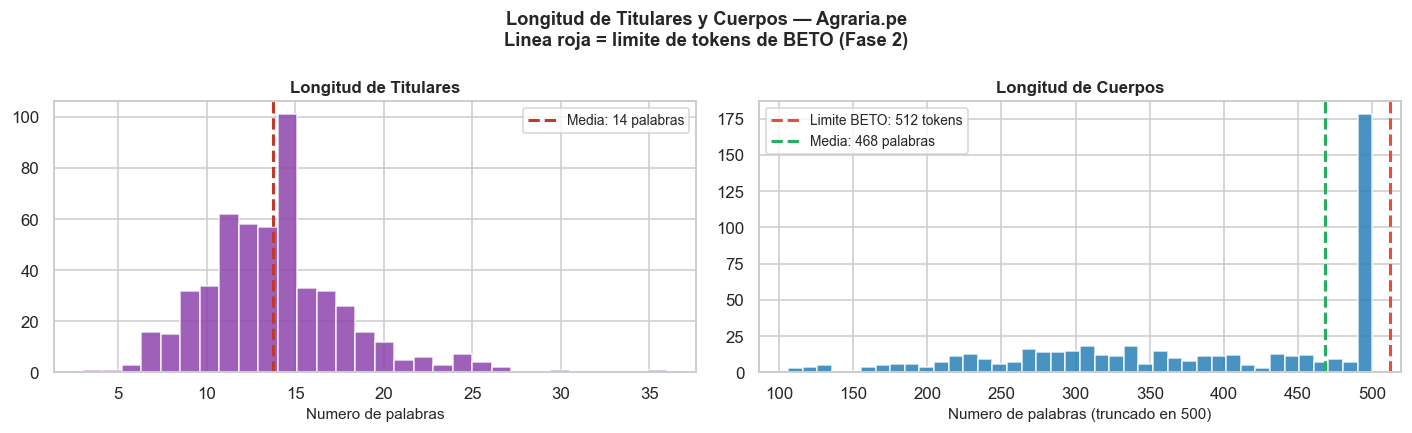

Guardado: pipeline/output/03_eda/act03_agraria_g3_longitud.png
Noticias que exceden 512 palabras (limite BETO): 29.7%


In [18]:
df_agr['len_titular'] = df_agr['titular'].fillna('').apply(lambda x: len(str(x).split()))
df_agr['len_cuerpo']  = df_agr['cuerpo_completo'].fillna('').apply(lambda x: len(str(x).split()))
cuerpo_valido = df_agr[df_agr['len_cuerpo'] > 0]['len_cuerpo']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_agr['len_titular'], bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axvline(df_agr['len_titular'].mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media: {df_agr["len_titular"].mean():.0f} palabras')
axes[0].set_xlabel('Numero de palabras', fontsize=10)
axes[0].set_title('Longitud de Titulares', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(cuerpo_valido.clip(upper=500), bins=40, color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].axvline(512, color='#e74c3c', linestyle='--', linewidth=2, label='Limite BETO: 512 tokens')
axes[1].axvline(cuerpo_valido.mean(), color='#27ae60', linestyle='--', linewidth=2,
                label=f'Media: {cuerpo_valido.mean():.0f} palabras')
axes[1].set_xlabel('Numero de palabras (truncado en 500)', fontsize=10)
axes[1].set_title('Longitud de Cuerpos', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Longitud de Titulares y Cuerpos — Agraria.pe\n'
             'Linea roja = limite de tokens de BETO (Fase 2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_agraria_g3_longitud.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
pct_excede = (cuerpo_valido > 512).mean() * 100
print(f'Noticias que exceden 512 palabras (limite BETO): {pct_excede:.1f}%')


### Interpretacion

**Que muestra:** La distribucion de longitud de titulares y cuerpos. La linea roja marca el limite de 512 tokens del modelo BETO.

**Implicacion para el pipeline:** Los cuerpos que exceden 512 palabras deberan truncarse en la Fase 2 antes de pasarlos a BETO. Para la Fase 1, la longitud no afecta el conteo mensual de noticias.

**Implicacion para el modelo:** Si la mayoria de los cuerpos exceden el limite, se evaluara si usar solo el titular o los primeros 512 tokens para el analisis de sentimiento.


---
# 5. Correlacion Cruzada entre Todas las Fuentes

Este es el grafico mas importante del EDA: muestra si las variables exogenas (clima, emergencias, noticias) tienen relacion con la variable objetivo (produccion de limon).


## Tabla resumen estadistico integrado


In [19]:
# Merge de todas las fuentes
df_master = prod_mensual.copy()
df_master = pd.merge(df_master, clima_nacional, on='fecha_mes', how='left')
df_master = pd.merge(df_master, emer_mensual, on='fecha_mes', how='left')
df_master = pd.merge(df_master, noticias_mensual, on='fecha_mes', how='left')
df_master['n_emergencias'] = df_master['n_emergencias'].fillna(0)
df_master['n_noticias']    = df_master['n_noticias'].fillna(0)

cols_stats = ['produccion_t','precio_kg','n_emergencias','n_noticias'] + VARS_CLIMA
cols_stats = [c for c in cols_stats if c in df_master.columns]

print('ESTADISTICAS DESCRIPTIVAS — DATASET INTEGRADO PRELIMINAR')
print('=' * 70)
display(df_master[cols_stats].describe().round(3))
df_master[cols_stats].describe().round(3).to_csv(OUTPUT['eda'] + 'act03_stats_integrado.csv')
print(f'\nMeses disponibles: {len(df_master)}')
print(f'Variables totales: {len(cols_stats)}')


ESTADISTICAS DESCRIPTIVAS — DATASET INTEGRADO PRELIMINAR


,produccion_t,precio_kg,n_emergencias,n_noticias,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M
count,116.000,116.000,116.000,116.000,56.000,56.000,56.000,56.000,56.000,56.000,56.000,56.000
mean,24666.401,1.388,116.267,4.310,17.785,1.834,11.530,72.252,18.340,26.930,11.674,1.625
std,8639.387,0.556,271.345,5.894,1.360,1.144,1.080,5.829,0.874,1.229,1.301,0.134
min,5267.080,0.892,0.000,0.000,14.905,0.326,9.659,61.667,16.189,24.669,8.530,1.382
25%,18620.858,1.018,0.000,0.000,16.862,0.792,10.628,67.026,17.833,25.862,10.840,1.515
50%,24044.135,1.254,0.000,0.000,17.443,1.523,11.629,73.436,18.351,26.903,11.880,1.618
75%,30302.028,1.567,0.000,8.000,18.946,2.574,12.408,77.368,18.746,27.879,12.626,1.737
max,45903.190,4.533,1378.000,26.000,21.426,4.739,13.497,81.582,20.209,29.285,13.862,1.868



Meses disponibles: 116
Variables totales: 12


## Grafico 16 — Correlacion cruzada entre todas las fuentes


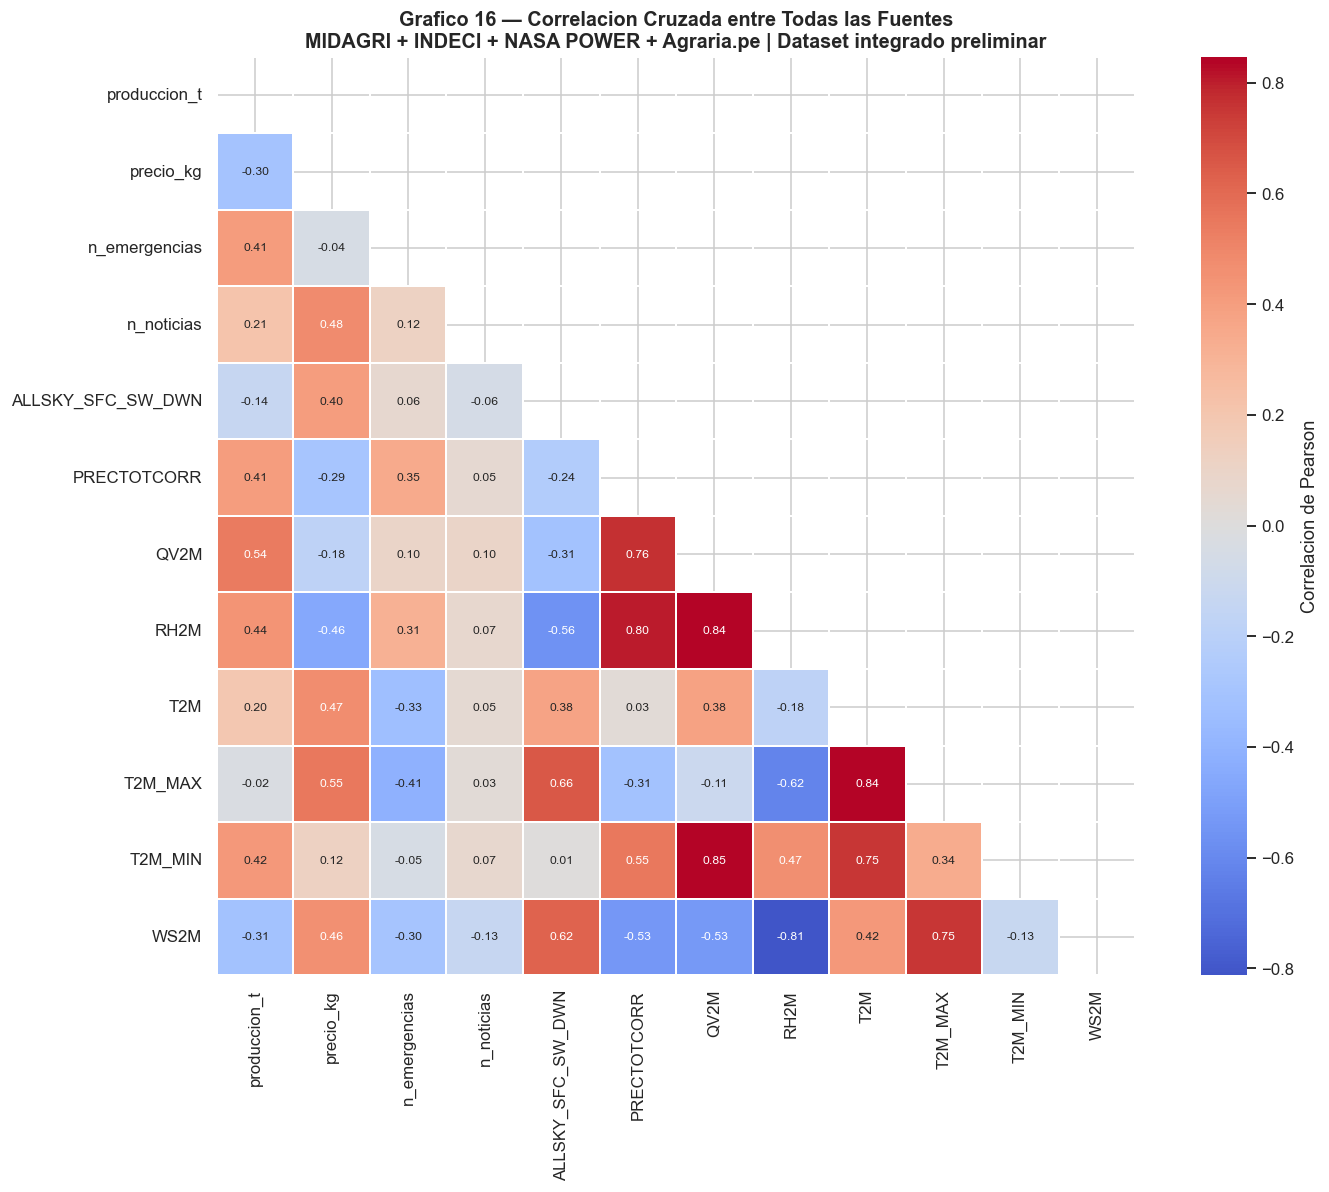

Guardado: pipeline/output/03_eda/act03_resumen_correlacion_cruzada.png

Correlaciones con produccion_t (variable objetivo):
  QV2M                      r =   0.539  [ALTA]
  RH2M                      r =   0.443  [MEDIA]
  T2M_MIN                   r =   0.422  [MEDIA]
  n_emergencias             r =   0.408  [MEDIA]
  PRECTOTCORR               r =   0.406  [MEDIA]
  WS2M                      r =  -0.308  [MEDIA]
  precio_kg                 r =  -0.304  [MEDIA]
  n_noticias                r =   0.214  [BAJA]
  T2M                       r =   0.198  [BAJA]
  ALLSKY_SFC_SW_DWN         r =  -0.138  [BAJA]
  T2M_MAX                   r =  -0.022  [BAJA]


In [20]:
cols_corr = ['produccion_t','precio_kg','n_emergencias','n_noticias'] + VARS_CLIMA
cols_corr = [c for c in cols_corr if c in df_master.columns]
corr_total = df_master[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_total, dtype=bool))
sns.heatmap(corr_total, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Grafico 16 — Correlacion Cruzada entre Todas las Fuentes\n'
             'MIDAGRI + INDECI + NASA POWER + Agraria.pe | Dataset integrado preliminar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_resumen_correlacion_cruzada.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Correlaciones con produccion_t (variable objetivo):')
corr_prod = corr_total['produccion_t'].drop('produccion_t').sort_values(key=abs, ascending=False)
for var, r in corr_prod.items():
    nivel = 'ALTA' if abs(r) > 0.5 else ('MEDIA' if abs(r) > 0.3 else 'BAJA')
    print(f'  {var:<25} r = {r:>7.3f}  [{nivel}]')


### Interpretacion

**Que muestra:** La correlacion de Pearson entre todas las variables del dataset integrado. La primera fila/columna (`produccion_t`) es la mas importante: muestra que variables tienen mayor relacion con la produccion de limon.

**Implicacion para el pipeline:** Las variables con correlacion alta con `produccion_t` son las mas valiosas para el modelo. Las variables con correlacion alta entre si (multicolinealidad) son candidatas a descarte en la Actividad 9.

**Implicacion para el modelo:** Este heatmap es la evidencia cuantitativa que justifica la arquitectura multimodal del LSTM-Attention. Si las variables exogenas tienen correlacion significativa con la produccion, el modelo multimodal superara a un modelo univariado.


---
# 6. Conclusiones del EDA


In [21]:
print('=' * 70)
print('  ACTIVIDAD 3 COMPLETADA — CONCLUSIONES DEL EDA')
print('=' * 70)
print()
print('MIDAGRI:')
print('  - Limon identificado como cultivo objetivo con produccion significativa.')
print('  - Estacionalidad mensual clara: justifica codificacion ciclica en Fase 2.')
print('  - Correlacion produccion-precio documentada.')
print()
print('INDECI:')
print('  - Fenomenos hidrometeorologicos dominantes: lluvias intensas y huaycos.')
print('  - Serie temporal de emergencias con picos estacionales (dic-mar).')
print('  - Correlacion con produccion documentada.')
print()
print('NASA POWER:')
print('  - 8 variables climaticas con estacionalidad clara.')
print('  - Pares de variables altamente correlacionadas identificados.')
print('  - Variables con mayor correlacion con produccion identificadas.')
print()
print('AGRARIA.PE:')
print('  - Cobertura mensual de noticias documentada.')
print('  - Longitud de cuerpos evaluada para Fase 2 (BETO).')
print()
graficos = sorted(glob.glob(OUTPUT['eda'] + 'act03_*.png'))
print(f'Total graficos generados: {len(graficos)}')
for g in graficos:
    print(f'  {os.path.basename(g)}')
print()
print('Proximos pasos:')
print('  Actividad 4 -> Calidad de datos (pipeline/actividad_04_calidad.ipynb)')


  ACTIVIDAD 3 COMPLETADA — CONCLUSIONES DEL EDA

MIDAGRI:
  - Limon identificado como cultivo objetivo con produccion significativa.
  - Estacionalidad mensual clara: justifica codificacion ciclica en Fase 2.
  - Correlacion produccion-precio documentada.

INDECI:
  - Fenomenos hidrometeorologicos dominantes: lluvias intensas y huaycos.
  - Serie temporal de emergencias con picos estacionales (dic-mar).
  - Correlacion con produccion documentada.

NASA POWER:
  - 8 variables climaticas con estacionalidad clara.
  - Pares de variables altamente correlacionadas identificados.
  - Variables con mayor correlacion con produccion identificadas.

AGRARIA.PE:
  - Cobertura mensual de noticias documentada.
  - Longitud de cuerpos evaluada para Fase 2 (BETO).

Total graficos generados: 18
  act03_agraria_g1_categorias.png
  act03_agraria_g2_serie.png
  act03_agraria_g3_longitud.png
  act03_indeci_g1_fenomenos.png
  act03_indeci_g2_dpto.png
  act03_indeci_g3_serie.png
  act03_indeci_g4_vs_producc